# xDESI Multi-Probe Low-Resolution Diagnostics

This notebook inspects the cached low-resolution products from the multi-probe NaMaster pipeline. It only reads the saved HDF5 map and measurement files; it does not rebuild raw survey maps. DESI maps use the DR9 `valid_for_cl` selection, `weight_imaging_mean1` imaging weights, and the DR9 random-count mask.

DES scalar x shear-E spectra are plotted in the positive-convergence convention used by the theory wrapper. The low-res product uses the DES Y3 harmonic-space paper's 32 equal-weight sqrt-spaced NaMaster bandpowers over `ell=8..2048` for all spectra. It is still not a full high-significance kSZ validation product: the harmonic kSZ reference analysis fits roughly `1000 < ell < 7000`, while this quick product covers only the low end of that range.

In [1]:
from pathlib import Path
import json
import sys

import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
if (HERE / 'multiprobe_namaster.py').exists():
    sys.path.insert(0, str(HERE))
elif (HERE / 'notebooks/xDESI/survey_measure/multiprobe_namaster.py').exists():
    sys.path.insert(0, str((HERE / 'notebooks/xDESI/survey_measure').resolve()))
else:
    sys.path.insert(0, str(Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/survey_measure')))

from multiprobe_namaster import theory_to_data_vector

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 160})

In [2]:
ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
PRODUCT_ROOT = ROOT / 'data/xDESI/processed/multiprobe_namaster/lowres'
MAPS = PRODUCT_ROOT / 'xdesi_multiprobe_maps_nside1024_lmax2048.h5'
MEAS = PRODUCT_ROOT / 'xdesi_multiprobe_cls_cov_nside1024_lmax2048.h5'

print('Maps:', MAPS)
print('Measurement:', MEAS)
assert MAPS.exists(), 'Run prepare_multiprobe_maps.py first.'
assert MEAS.exists(), 'Run measure_multiprobe_namaster.py first.'

Maps: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/lowres/xdesi_multiprobe_maps_nside1024_lmax2048.h5
Measurement: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster/lowres/xdesi_multiprobe_cls_cov_nside1024_lmax2048.h5


AssertionError: Run measure_multiprobe_namaster.py first.

In [ ]:
with h5py.File(MEAS, 'r') as h5:
    cfg = json.loads(h5.attrs['config_json'])
    names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5['joint/spectrum_names'][:]]
    data_vector = h5['joint/data_vector'][:]
    cov_diag = np.diag(h5['joint/cov'][:])
    diag = json.loads(h5['joint'].attrs['diagnostics_json'])

print(json.dumps(cfg, indent=2))
print('n_spectra:', len(names))
print('data_vector length:', data_vector.size)
print('cov diag min/max:', np.nanmin(cov_diag), np.nanmax(cov_diag))
print(json.dumps(diag, indent=2))

{
  "act_downgrade": 4,
  "catalog_chunk": 2000000,
  "compute_covariance": true,
  "compute_covariance_eigenvalues": true,
  "covariance_dl_band": -1,
  "covariance_l_exact": -1,
  "covariance_l_toeplitz": -1,
  "des_y3_source_nz_fits": "/mnt/ceph/users/spandey/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits",
  "ell_min": 8,
  "include_ksz_velocity_shuffle": true,
  "ksz_shuffle_seed": 12345,
  "lmax": 1024,
  "n_bins": 24,
  "n_iter": 0,
  "n_iter_mask": 0,
  "nside": 1024,
  "output_dir": "data/xDESI/processed/multiprobe_namaster",
  "shear_e_to_kappa_sign": -1.0,
  "shear_mask_dataset": "mask_weight",
  "shear_noise_attr": "shape_noise_pseudo_cl_normalized_weight_mask",
  "stage": "lowres",
  "subtract_masked_mean": true
}
n_spectra: 46
data_vector length: 1104
cov diag min/max: 3.111119170073197e-28 7.731889411271462e-10
{
  "condition_positive": 5.176929639088007e+22,
  "diag_max": 7.731889411271462e-10,
  "diag_min": 3.111119170073197e-28,
  "eig_

/tmp/ipykernel_3801981/2493814572.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


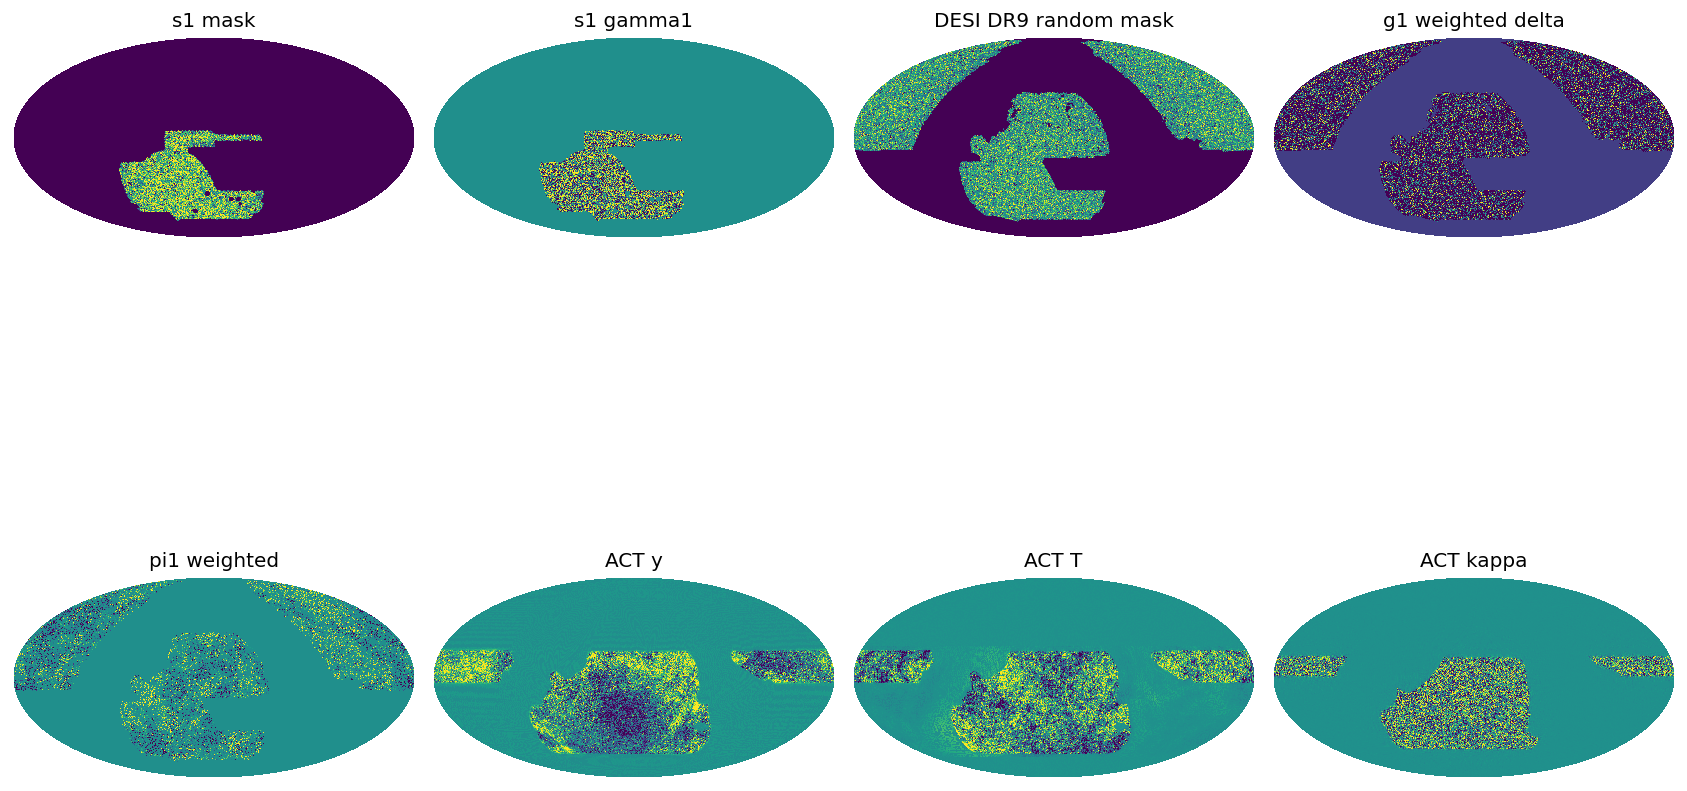

In [4]:
def read_field(h5, name):
    g = h5[f'fields/{name}']
    mask = h5[f"masks/{g.attrs['mask_ref']}"][:]
    maps = [g[f'map{i}'][:] for i in range(len([k for k in g if k.startswith('map')]))]
    return mask, maps

with h5py.File(MAPS, 'r') as h5:
    panels = [
        ('s1 mask', h5['masks/des_shear_tomo1'][:]),
        ('s1 gamma1', read_field(h5, 's1')[1][0]),
        ('DESI DR9 random mask', h5['masks/desi_dr9_random'][:]),
        ('g1 weighted delta', read_field(h5, 'g1')[1][0]),
        ('pi1 weighted', read_field(h5, 'pi1')[1][0]),
        ('ACT y', read_field(h5, 'y')[1][0]),
        ('ACT T', read_field(h5, 'T')[1][0]),
        ('ACT kappa', read_field(h5, 'kappa')[1][0]),
    ]

fig = plt.figure(figsize=(14, 9))
for i, (title, m) in enumerate(panels, start=1):
    finite = np.isfinite(m) & (m != hp.UNSEEN)
    if np.any(finite):
        lo, hi = np.nanpercentile(m[finite], [2, 98])
    else:
        lo, hi = None, None
    hp.mollview(m, fig=fig.number, sub=(2, 4, i), title=title, min=lo, max=hi, cbar=False)
plt.tight_layout()

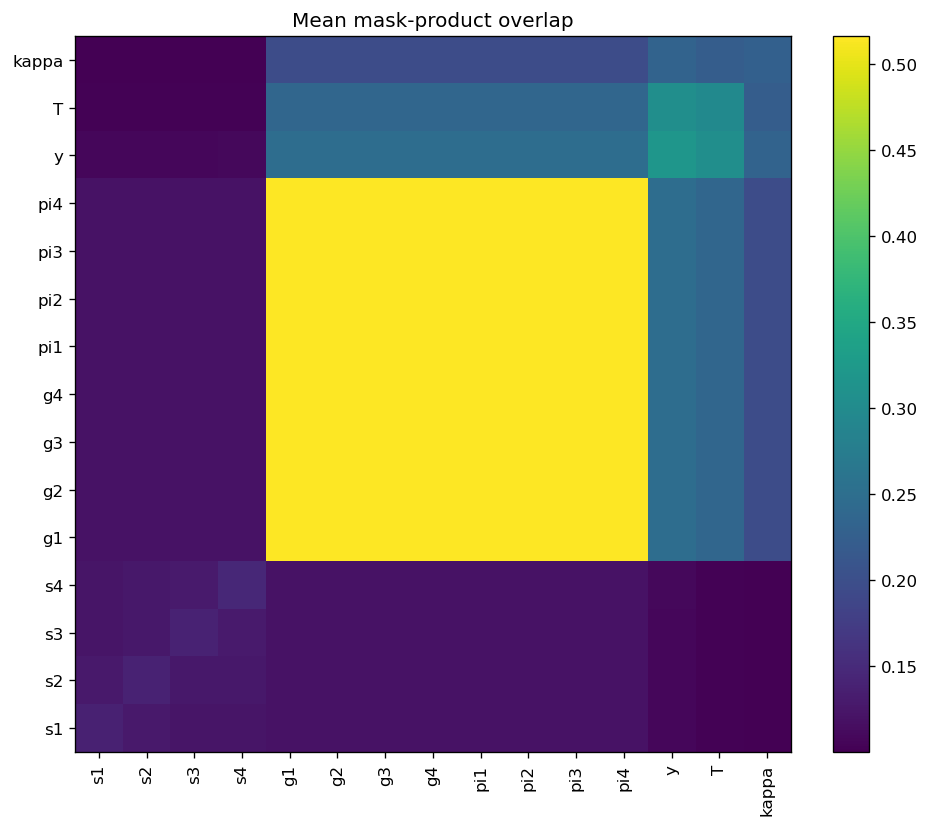

In [5]:
with h5py.File(MAPS, 'r') as h5:
    field_names = ['s1', 's2', 's3', 's4', 'g1', 'g2', 'g3', 'g4', 'pi1', 'pi2', 'pi3', 'pi4', 'y', 'T', 'kappa']
    masks = {}
    for name in field_names:
        g = h5[f'fields/{name}']
        masks[name] = h5[f"masks/{g.attrs['mask_ref']}"][:]

overlap = np.zeros((len(field_names), len(field_names)))
for i, a in enumerate(field_names):
    for j, b in enumerate(field_names):
        overlap[i, j] = np.mean(masks[a] * masks[b])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(overlap, origin='lower')
ax.set_xticks(range(len(field_names)), field_names, rotation=90)
ax.set_yticks(range(len(field_names)), field_names)
ax.set_title('Mean mask-product overlap')
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

pz1 sigma_rec_w= 0.00030257317276520713 shot_w= 2.0155793194326728e-06 nbar_w/sr= 496467.07068159006 weight= catalog/weight_imaging_mean1
pz2 sigma_rec_w= 0.0002666096702398312 shot_w= 1.1869599308129612e-06 nbar_w/sr= 842669.0425462222 weight= catalog/weight_imaging_mean1
pz3 sigma_rec_w= 0.00025221539207657365 shot_w= 9.105195050314217e-07 nbar_w/sr= 1099293.6949371542 weight= catalog/weight_imaging_mean1
pz4 sigma_rec_w= 0.00024196428875874337 shot_w= 9.956887522546362e-07 nbar_w/sr= 1006018.1407083767 weight= catalog/weight_imaging_mean1


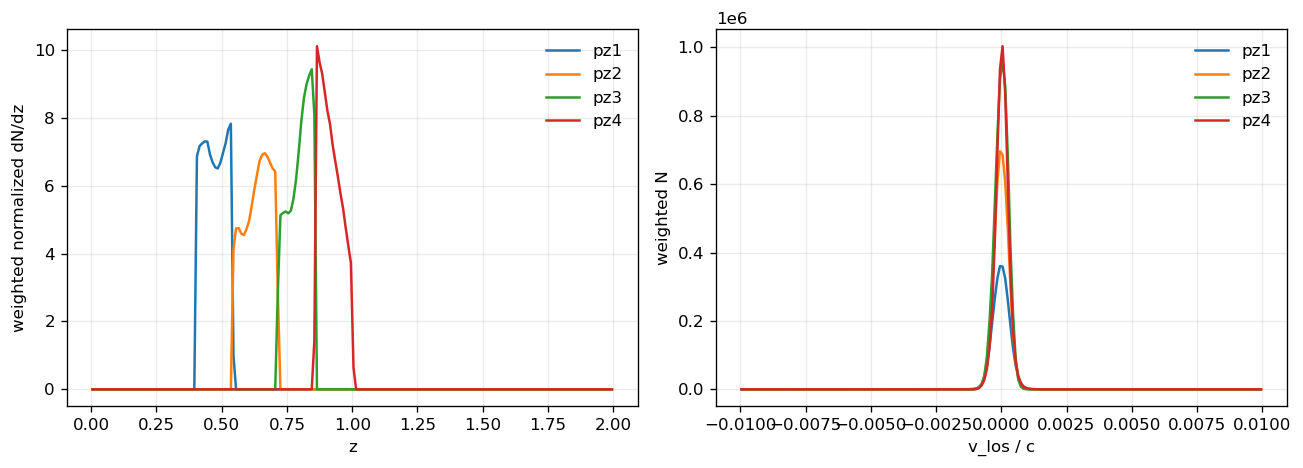

In [6]:
with h5py.File(MAPS, 'r') as h5:
    z = h5['nz/desi/z_mid'][:]
    nz = h5['nz/desi/nz_dndz_by_pz'][:]
    vr = h5['nz/desi/vr_mid'][:]
    vh = h5['nz/desi/vr_weighted_counts_by_pz'][:] if 'vr_weighted_counts_by_pz' in h5['nz/desi'] else h5['nz/desi/vr_counts_by_pz'][:]
    summary = json.loads(h5['nz/desi'].attrs['summary_json'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(4):
    axes[0].plot(z, nz[i], label=f'pz{i+1}')
    axes[1].plot(vr, vh[i], label=f'pz{i+1}')
axes[0].set_xlabel('z')
axes[0].set_ylabel('weighted normalized dN/dz')
axes[1].set_xlabel('v_los / c')
axes[1].set_ylabel('weighted N')
for ax in axes:
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
fig.tight_layout()

for key, val in summary.items():
    print(key, 'sigma_rec_w=', val.get('sigma_rec_vr_over_c_weighted', val['sigma_rec_vr_over_c']), 'shot_w=', val['shot_noise'], 'nbar_w/sr=', val['nbar_per_sr'], 'weight=', val.get('weight_dataset'))

shear_e_to_kappa_sign: -1.0 (scalar x shear-E should match positive-convergence theory)
des_shear_EE: joint SNR = 18.9
act_y_des_shear_E: joint SNR = 5.2
desi_g_auto: joint SNR = 526.0
desi_g_act_y: joint SNR = 31.7
desi_g_des_shear_E: joint SNR = 19.4
desi_g_act_kappa: joint SNR = 46.6
desi_pi_act_T: joint SNR = 9.5


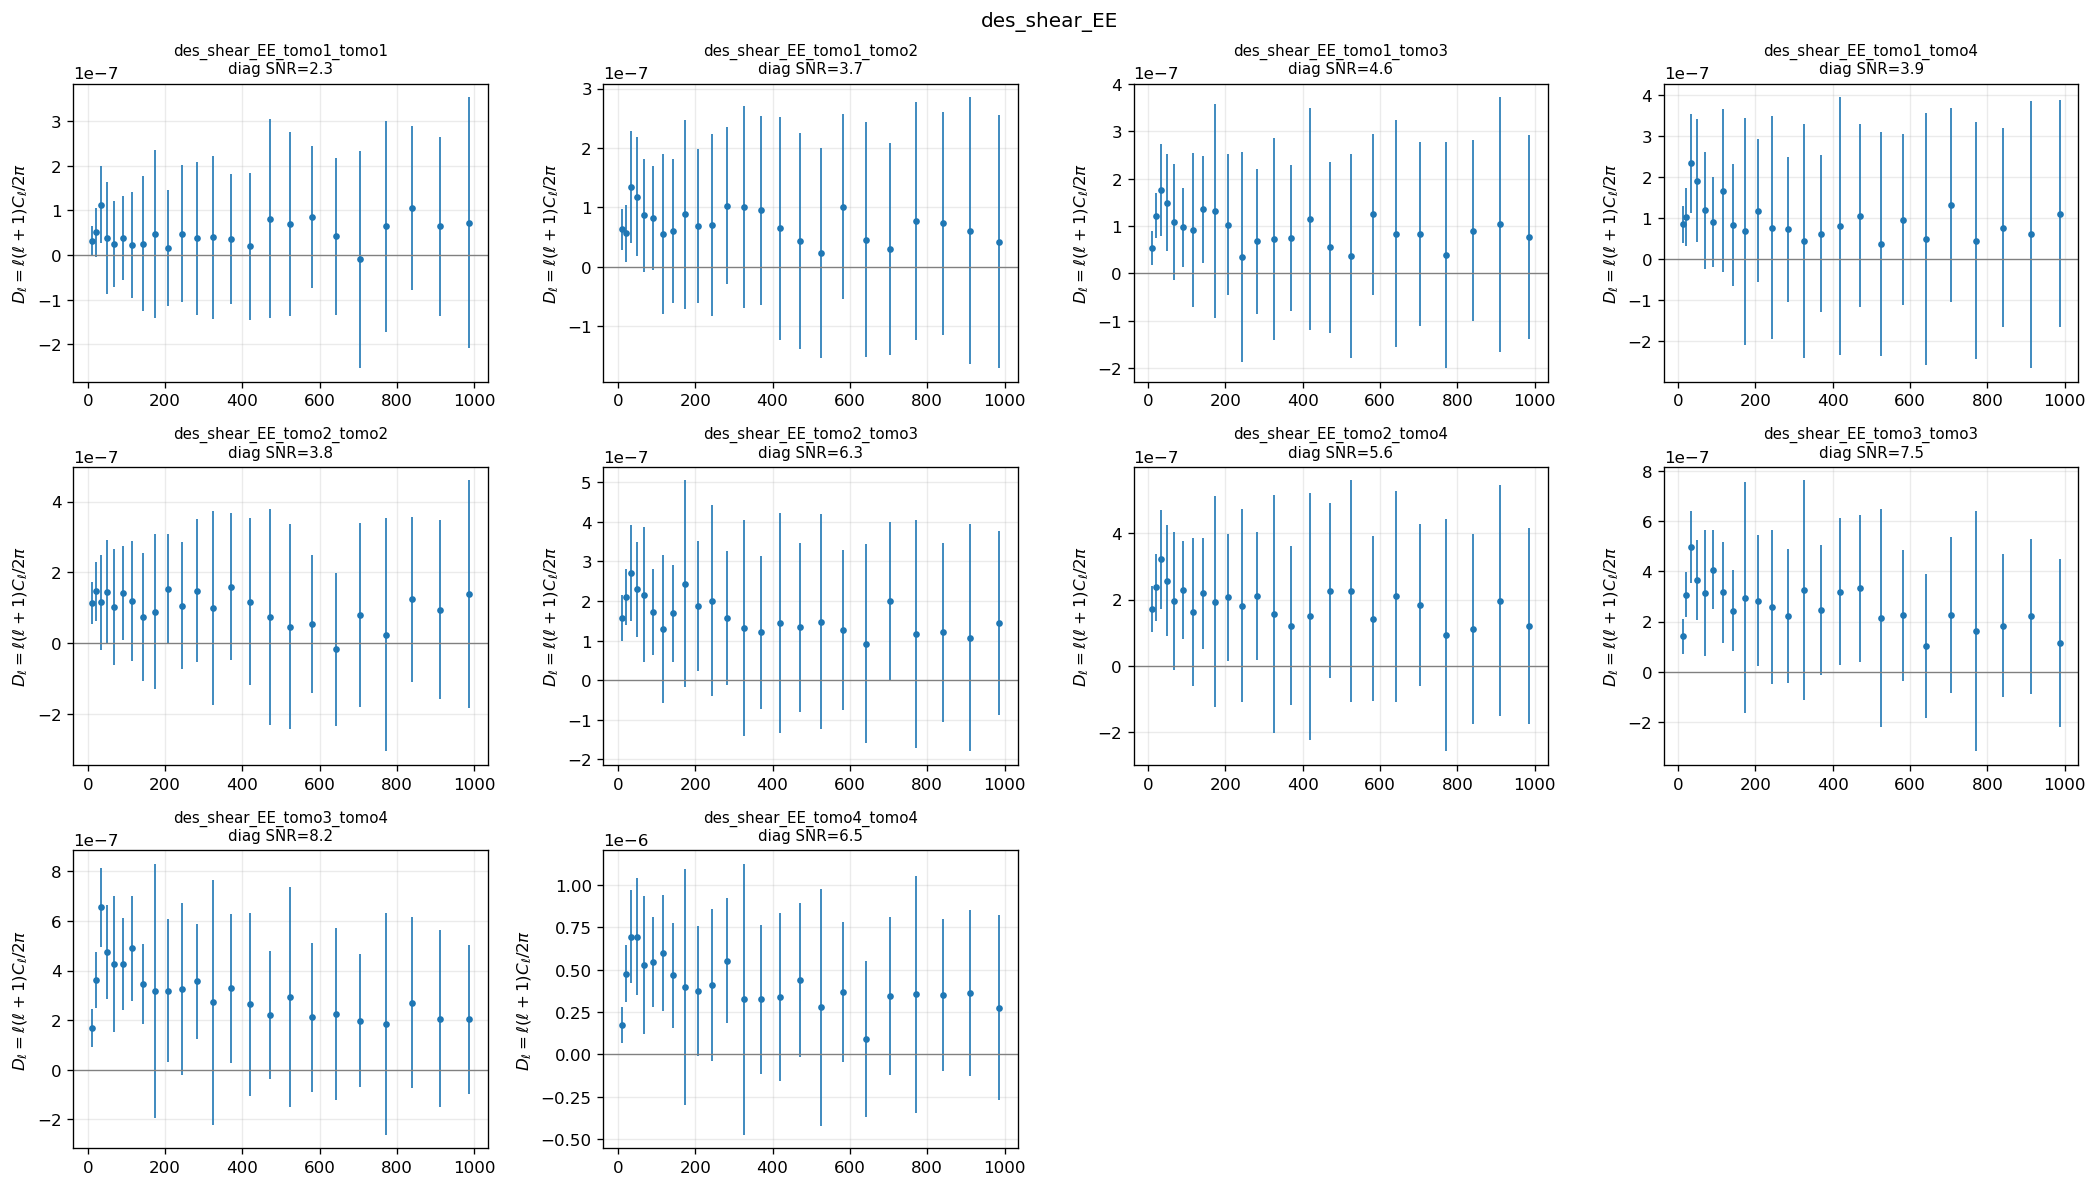

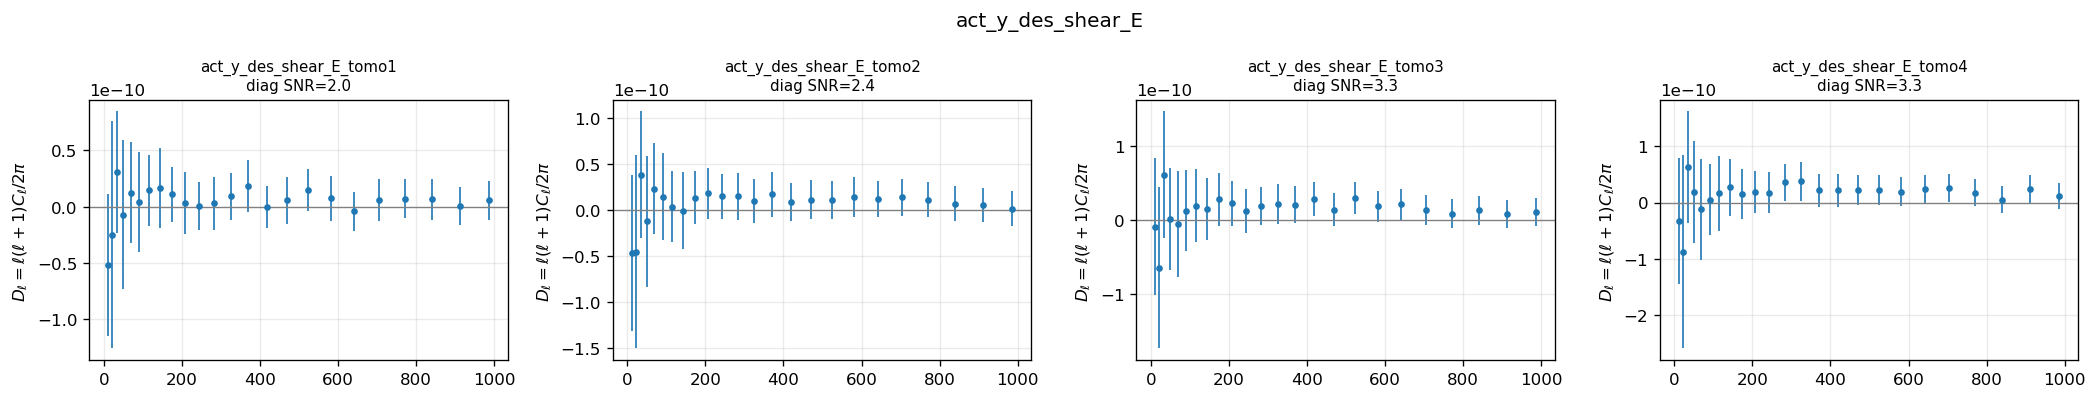

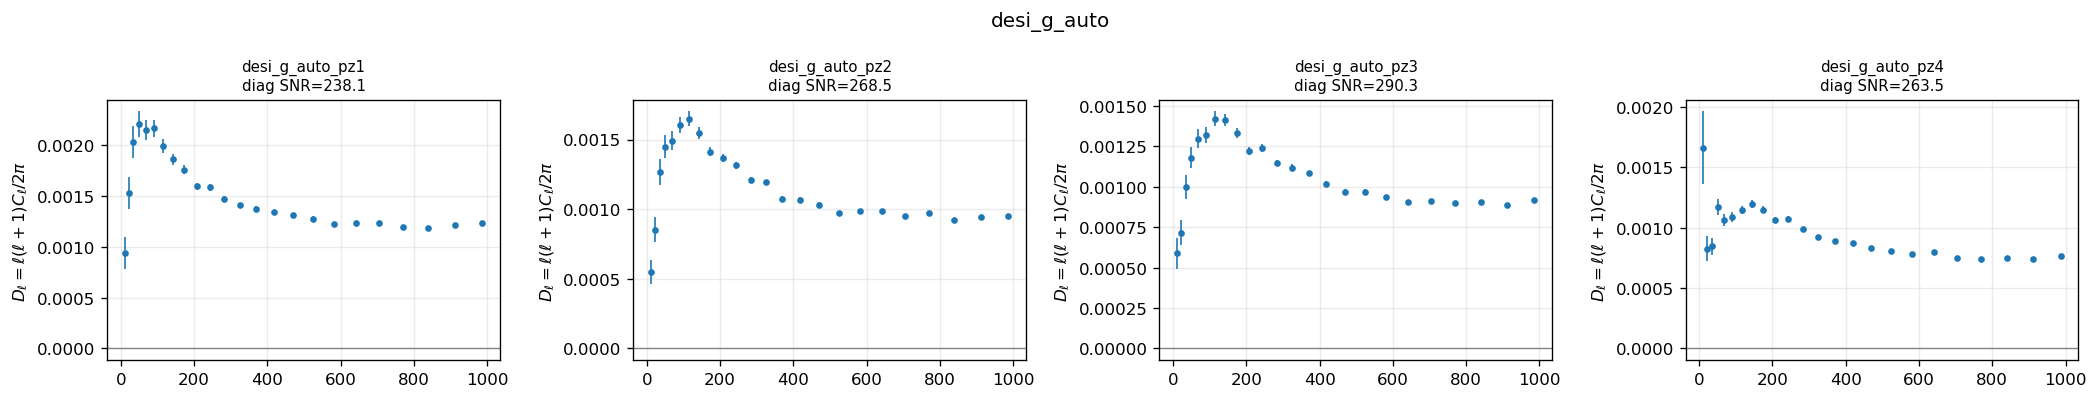

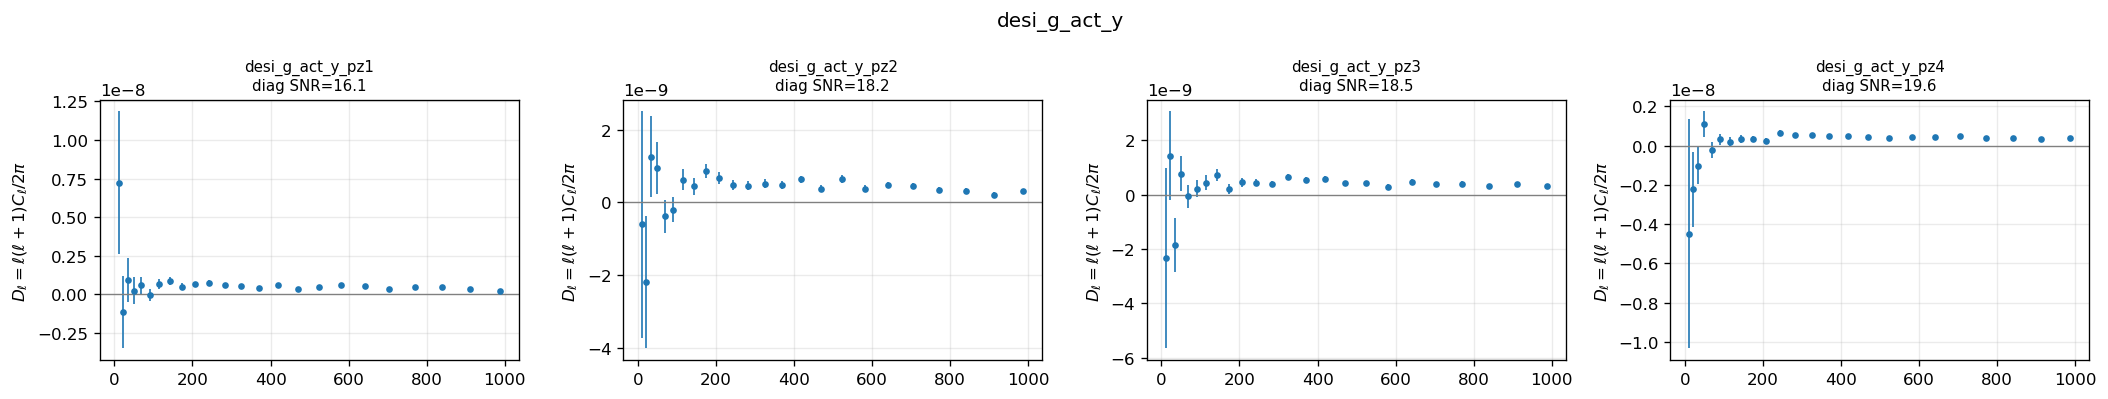

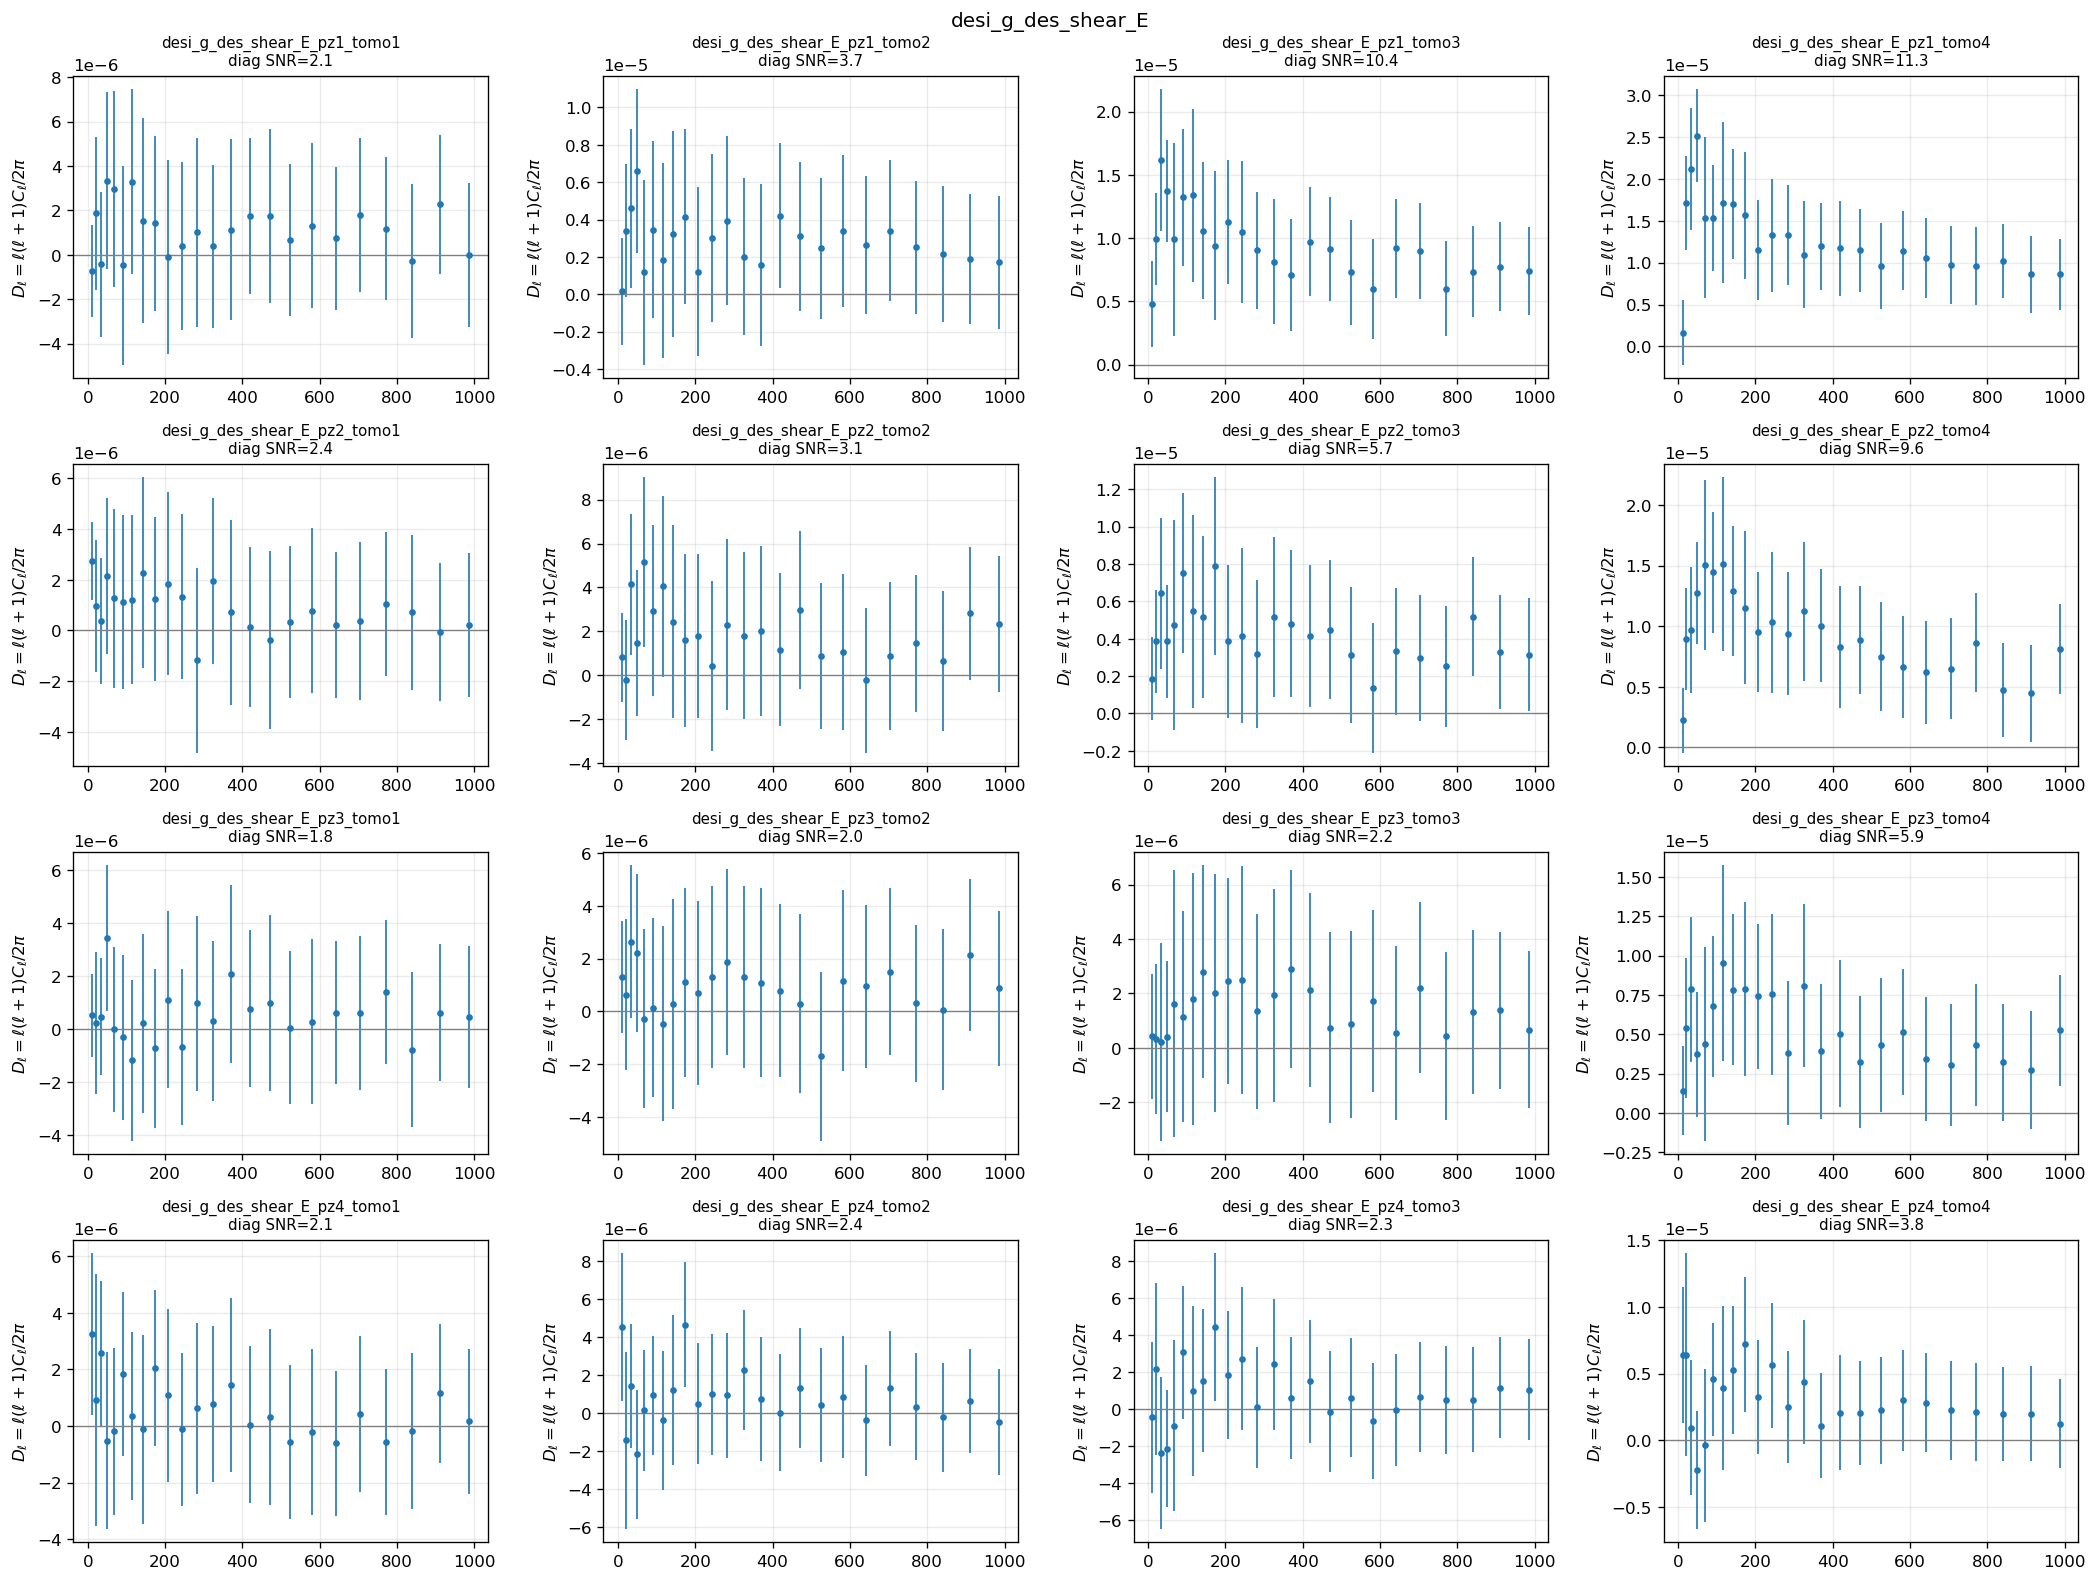

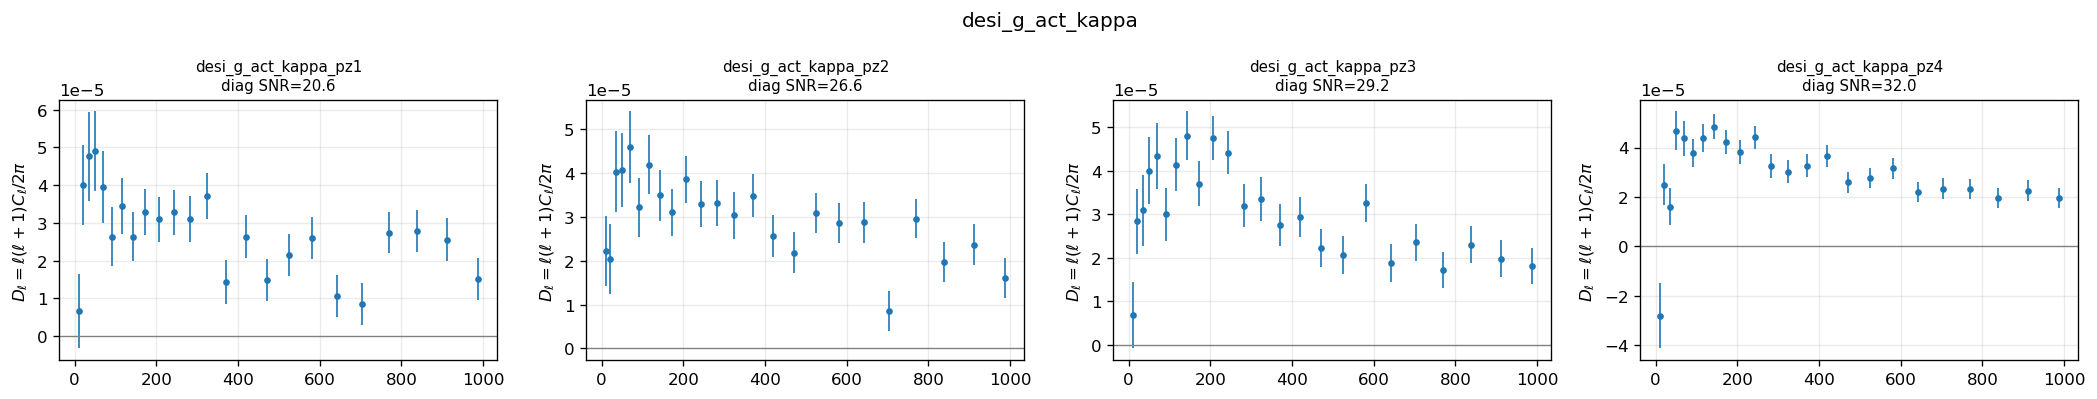

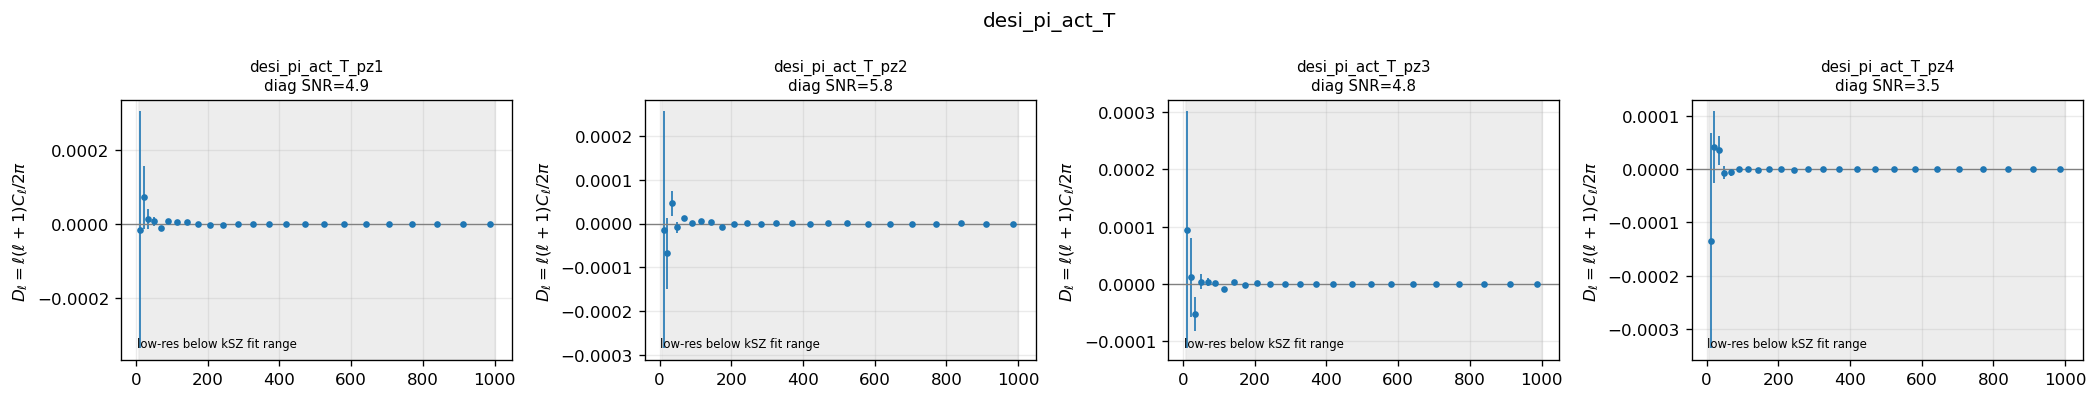

In [7]:
families = [
    'des_shear_EE', 'act_y_des_shear_E', 'desi_g_auto', 'desi_g_act_y',
    'desi_g_des_shear_E', 'desi_g_act_kappa', 'desi_pi_act_T'
]

def diagonal_spectrum_snr(group):
    if 'cov' not in group:
        return np.nan
    cl = group['cl'][:]
    err = np.sqrt(np.clip(np.diag(group['cov'][:]), 0.0, np.inf))
    good = np.isfinite(cl) & np.isfinite(err) & (err > 0)
    return float(np.sqrt(np.sum((cl[good] / err[good]) ** 2))) if np.count_nonzero(good) else np.nan

def family_joint_snr(h5, spectrum_names, joint_cov, joint_data):
    joint_names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5['joint/spectrum_names'][:]]
    nbin = len(h5['joint/ell'][:])
    index = []
    for name in spectrum_names:
        i = joint_names.index(name)
        index.extend(range(i * nbin, (i + 1) * nbin))
    index = np.asarray(index)
    cov = joint_cov[np.ix_(index, index)]
    data = joint_data[index]
    err = np.sqrt(np.clip(np.diag(cov), 0.0, np.inf))
    good = np.isfinite(data) & np.isfinite(err) & (err > 0)
    if not np.count_nonzero(good):
        return np.nan
    inv = np.linalg.pinv(cov[np.ix_(good, good)], rcond=1e-12)
    return float(np.sqrt(max(data[good] @ inv @ data[good], 0.0)))

with h5py.File(MEAS, 'r') as h5:
    cfg = json.loads(h5.attrs['config_json'])
    shear_sign = cfg.get('shear_e_to_kappa_sign', None)
    if shear_sign is not None:
        print('shear_e_to_kappa_sign:', shear_sign, '(scalar x shear-E should match positive-convergence theory)')
    joint_cov = h5['joint/cov'][:]
    joint_data = h5['joint/data_vector'][:]
    for family in families:
        spec_names = [name for name in h5['spectra'] if h5[f'spectra/{name}'].attrs['family'] == family]
        print(f'{family}: joint SNR = {family_joint_snr(h5, spec_names, joint_cov, joint_data):.1f}')
        ncols = min(4, max(1, len(spec_names)))
        nrows = int(np.ceil(len(spec_names) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.4*ncols, 3.35*nrows), squeeze=False)
        for ax, name in zip(axes.ravel(), spec_names):
            g = h5[f'spectra/{name}']
            ell = g['ell'][:]
            cl = g['cl'][:]
            err = g['err'][:] if 'err' in g else None
            # scale = ell * (ell + 1.0) / (2.0 * np.pi)
            scale = ell 
            y = scale * cl
            if err is not None:
                ax.errorbar(ell, y, yerr=scale * err, fmt='o', ms=3, lw=1)
            else:
                ax.plot(ell, y, 'o-', ms=3)
            if family == 'desi_pi_act_T':
                ax.axvspan(8, 1000, color='0.9', alpha=0.7, zorder=-10)
                ax.text(0.04, 0.05, 'low-res below kSZ fit range', transform=ax.transAxes, fontsize=7)
            ax.axhline(0, color='0.5', lw=0.8)
            # ax.set_xscale('log')
            snr = diagonal_spectrum_snr(g)
            title = name if not np.isfinite(snr) else f'{name}\ndiag SNR={snr:.1f}'
            ax.set_title(title, fontsize=9)
            ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
            ax.grid(alpha=0.25)
        for ax in axes.ravel()[len(spec_names):]:
            ax.axis('off')
        fig.suptitle(family)
        fig.tight_layout()


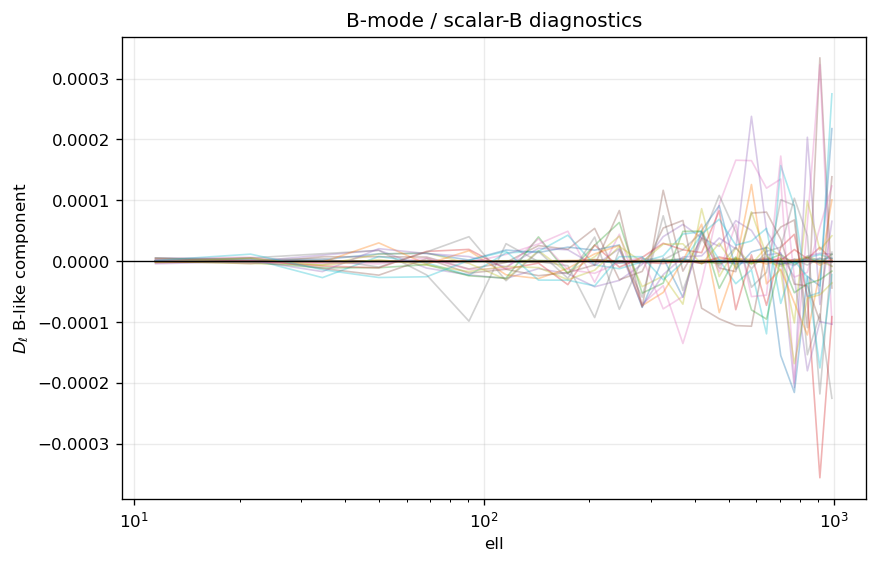

In [8]:
with h5py.File(MEAS, 'r') as h5:
    names = [name for name in h5['spectra'] if h5[f'spectra/{name}/cl_all_components'].shape[0] > 1]
    fig, ax = plt.subplots(figsize=(8, 5))
    for name in names:
        g = h5[f'spectra/{name}']
        labels = json.loads(g.attrs['component_labels'])
        cl_all = g['cl_all_components'][:]
        ell = g['ell'][:]
        scale = ell * (ell + 1.0) / (2.0 * np.pi)
        b_index = 3 if labels == ['EE', 'EB', 'BE', 'BB'] else 1
        ax.plot(ell, scale * cl_all[b_index], alpha=0.35, lw=1)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('ell')
    ax.set_ylabel(r'$D_\ell$ B-like component')
    ax.set_title('B-mode / scalar-B diagnostics')
    ax.grid(alpha=0.25)


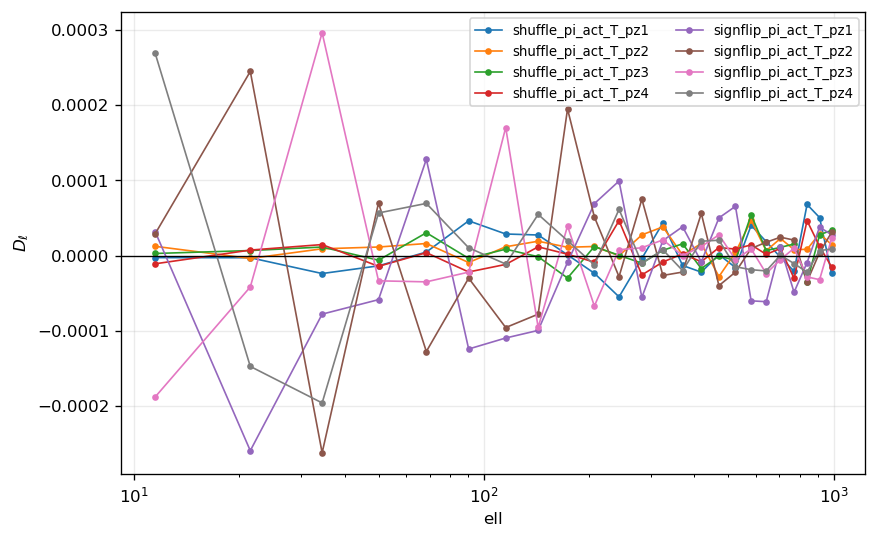

In [9]:
with h5py.File(MEAS, 'r') as h5:
    if 'null_tests' in h5 and len(h5['null_tests']) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        for name in h5['null_tests']:
            g = h5[f'null_tests/{name}']
            ell = g['ell'][:]
            cl = g['cl'][:]
            scale = ell * (ell + 1.0) / (2.0 * np.pi)
            ax.plot(ell, scale * cl, marker='o', ms=3, lw=1, label=name)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xscale('log')
        ax.set_xlabel('ell')
        ax.set_ylabel(r'$D_\ell$')
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.25)
    else:
        print('No null tests saved in this measurement product.')


In [10]:
# Theory overlay hook. Provide unbinned full-sky C_ell arrays keyed by the
# exact saved spectrum names, or for kSZ by desi_g_tau_pz{i} plus A_v amplitudes.
# Example:
# theory = {'desi_g_auto_pz1': cl_gg_1, ...}
# model_dv, model_names = theory_to_data_vector(MEAS, theory, ell=ell_theory,
#                                               ksz_velocity_amplitudes={1: A1, 2: A2, 3: A3, 4: A4})
print('Use theory_to_data_vector(...) after DES source n(z) and ACT transfer choices are finalized.')

Use theory_to_data_vector(...) after DES source n(z) and ACT transfer choices are finalized.
